In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
BATCH_SIZE = 128
LEARNING_RATE = 0.001
EPOCHS = 30
NUM_CLASSES = 10

In [3]:
transform_train = transforms.Compose([
    
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

transform_test = transforms.Compose([
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

In [5]:
train_dataset = torchvision.datasets.CIFAR10(
    root='../data/CIFAR10',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root='../data/CIFAR10',
    train=False,
    download=True,
    transform=transform_test
)

100%|██████████| 170M/170M [00:30<00:00, 5.63MB/s] 


In [6]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [7]:
classes = train_dataset.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [9]:
class CNNClassifier(nn.Module):
    
    def __init__(self):
        super(CNNClassifier, self).__init__()
        
        self.features = nn.Sequential(
            
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.MaxPool2d(2),
            
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.MaxPool2d(2),
            
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            
            nn.Dropout(0.5),
            
            nn.Linear(256, NUM_CLASSES)
        )
    
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        
        return x

In [10]:
model = CNNClassifier()
print(model)

CNNClassifier(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding

In [11]:
criterion = nn.CrossEntropyLoss()

In [12]:
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

In [13]:
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

In [14]:
def train_model():
    
    train_losses = []
    
    for epoch in range(EPOCHS):

        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        scheduler.step()
        
        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f}")
    
    return train_losses

In [15]:
train_losses = train_model()

Epoch 1/30 - Loss: 1.5734
Epoch 2/30 - Loss: 1.1639
Epoch 3/30 - Loss: 1.0114
Epoch 4/30 - Loss: 0.9229
Epoch 5/30 - Loss: 0.8681
Epoch 6/30 - Loss: 0.8163
Epoch 7/30 - Loss: 0.7822
Epoch 8/30 - Loss: 0.7430
Epoch 9/30 - Loss: 0.7135
Epoch 10/30 - Loss: 0.6832
Epoch 11/30 - Loss: 0.6026
Epoch 12/30 - Loss: 0.5799
Epoch 13/30 - Loss: 0.5699
Epoch 14/30 - Loss: 0.5519
Epoch 15/30 - Loss: 0.5416
Epoch 16/30 - Loss: 0.5292
Epoch 17/30 - Loss: 0.5140
Epoch 18/30 - Loss: 0.4974
Epoch 19/30 - Loss: 0.4942
Epoch 20/30 - Loss: 0.4819
Epoch 21/30 - Loss: 0.4414
Epoch 22/30 - Loss: 0.4340
Epoch 23/30 - Loss: 0.4246
Epoch 24/30 - Loss: 0.4196
Epoch 25/30 - Loss: 0.4145
Epoch 26/30 - Loss: 0.4090
Epoch 27/30 - Loss: 0.4023
Epoch 28/30 - Loss: 0.4024
Epoch 29/30 - Loss: 0.3921
Epoch 30/30 - Loss: 0.3901


In [16]:
def evaluate_model():
    
    model.eval()
    
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    
    with torch.no_grad():
        
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    
    
    accuracy = 100 * correct / total
    
    print(f"\nTest Accuracy: {accuracy:.2f}%")
    
    return all_preds, all_labels

In [17]:
preds, labels = evaluate_model()


Test Accuracy: 86.49%


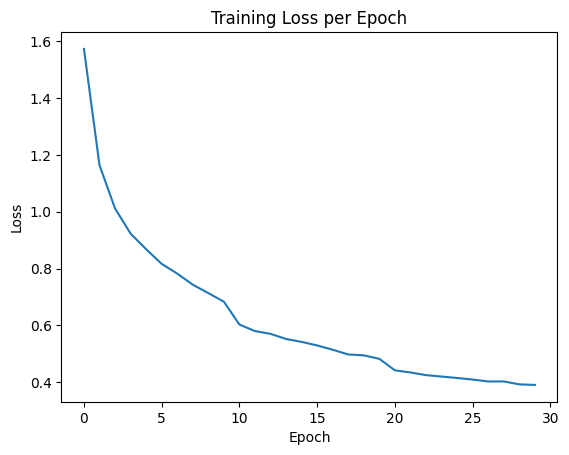

In [18]:
plt.plot(train_losses)
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [19]:
cm = confusion_matrix(labels, preds)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[889   7  49   5   6   0   1   8  25  10]
 [ 11 939   3   1   0   0   1   2   9  34]
 [ 24   0 838  25  47  21  29  12   2   2]
 [  7   1  61 728  34 105  20  29   8   7]
 [  6   0  42  32 863  11  20  25   1   0]
 [  4   0  40 118  32 779   4  23   0   0]
 [  4   0  47  42  11  12 877   2   3   2]
 [  9   0  30  19  28  20   0 891   0   3]
 [ 44   7  11   5   1   0   0   2 924   6]
 [ 20  33   3   7   0   0   1   1  14 921]]


In [20]:
print("\nClassification Report:")
print(classification_report(labels, preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1000
           1       0.95      0.94      0.95      1000
           2       0.75      0.84      0.79      1000
           3       0.74      0.73      0.73      1000
           4       0.84      0.86      0.85      1000
           5       0.82      0.78      0.80      1000
           6       0.92      0.88      0.90      1000
           7       0.90      0.89      0.89      1000
           8       0.94      0.92      0.93      1000
           9       0.94      0.92      0.93      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.87     10000
weighted avg       0.87      0.86      0.87     10000

